# Bad Honnef Exoplanetary School
## Exoplanets JWST Transmission spectroscopy

In order to perform exoplanet transmission spectroscopy with JWST one requires to obtain time-series spectra of the exoplanet host star.

In this practical exercise, we will now go through an example of obtaining an exoplanet transmission spectrum. As already explained, this is a spectrum of the exoplanet size as a function of wavelength, whose variability depends on the atmospheric constituents and properties of the transiting planet. The observations have already been reduced and the spectra of the exoplanet host star during the transit, as well as the reference stars are saved as pickle files, which you can get from the school's Github repository.

The observations of one transit of WASP-96b have been made with the [NIRISS/SOSS](https://jwst-docs.stsci.edu/jwst-near-infrared-imager-and-slitless-spectrograph) instrument at the JWST as part of the JWST Early Release Observations (ERO).

Here are the steps that you are expected to take to obtain the transmission spectrum from these spectra:

1.   Clone the school's [GitHub](https://github.com/bh-atmospheres/summer-schoool-2025/) respository
2.   Read the data using astropy fits module, and familiarize yourself with the data structure (dictionaries)
3.   Plot spectra for each dataset
4.   Normalise the spectra
5.   Integrate the spectra over the whole wavelength range to obtain white light curves (WLC), and plot them
6.   Normalize this differential LC by fitting an appropriate polynomial to the out of transit data (Note: Ideally, the out-of-transit polynomial is fitted simultaneously with the transit light curve and any other systematics. )
7.   Model this broadband (white) LC using the analytical transit model of [Mandel & Agol (2002)](https://ui.adsabs.harvard.edu/abs/2002ApJ...580L.171M/abstract), implemented in python (e.g. [${\tt exoplanet}$](https://docs.exoplanet.codes/en/v0.4.3/tutorials/transit/), [${\tt PyTransit}$](https://github.com/hpparvi/PyTransit), [${\tt batman}$](https://lkreidberg.github.io/batman/docs/html/index.html), etc.), obtaining parameter solutions by using MCMC or Nested Sampling to derive posterior distributions (Bayesian Framework).
8.   Obtain narrowband/spectroscopic LCs by integrating the spectra again using spectroscopic bins
9.   Model these LCs, but this time fixing those non-wavelenegth dependant parameters to the results obtained from the broadband LC fit (a/Rs, inc, etc.)
10.  Plot the transmission spectrum, i.e. $R_p/R_\star$ as the function of $\lambda$





In [3]:
# Step 1: cloning the respository
!git clone https://github.com/bh-atmospheres/summer-schoool-2025/
!pip install mpld3 # interactive matplotlib widget

Cloning into 'summer-schoool-2025'...
remote: Enumerating objects: 222, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 222 (delta 16), reused 23 (delta 9), pack-reused 160 (from 1)
Receiving objects: 100% (222/222), 226.76 MiB | 34.02 MiB/s, done.
Resolving deltas: 100% (100/100), done.
Updating files: 100% (51/51), done.
Error downloading object: pRT/input_data_BH.zip (b63df60): Smudge error: Error downloading pRT/input_data_BH.zip (b63df60f7d000aa6c0bb48aa1da1dd348f39126274ed8b74d77dc111cdc6b1c2): batch response: This repository exceeded its LFS budget. The account responsible for the budget should increase it to restore access.

Errors logged to /content/summer-schoool-2025/.git/lfs/logs/20250721T110526.321767122.log
Use `git lfs logs last` to view the log.
error: external filter 'git-lfs filter-process' failed
fatal: pRT/input_data_BH.zip: smudge filter lfs failed
You can inspect what was checked out with 'git stat

In [4]:
from astropy.io import fits

In [5]:
# Step 2: reading the data
import numpy as np
spec = fits.open('/content/summer-schoool-2025/JWST/WASP-96b/WASP-96_box_spectra_fullres.fits')
print(spec.info())


fluxes = spec[3].data
fluxes_err = spec[4].data
wave1 = spec[1].data
wave1_err = spec[2].data

time = spec[9].data - spec[9].data[0]

fluxes_o2 = spec[7].data
fluxes_err_o2 = spec[8].data
wave2 = spec[5].data
wave2_err = spec[6].data

print(wave1)
pixel_no = len(wave1)
wave_low = [wave1[0] - (wave1[1]-wave1[0])/2]
wave_high = [wave1[0] + (wave1[1]-wave1[0])/2]
for i in range(pixel_no)[1:]:
    h = wave1[i] - wave1[i-1]
    wave_low.append(wave1[i]-h/2)
    wave_high.append(wave1[i]+h/2)

pixel_no_o2 = len(wave2)
wave_low_o2 = [wave2[0] - (wave2[1]-wave2[0])/2]
wave_high_o2 = [wave2[0] + (wave2[1]-wave2[0])/2]
for i in range(pixel_no_o2)[1:]:
    h_o2 = wave2[i] - wave2[i-1]
    wave_low_o2.append(wave2[i]-h/2)
    wave_high_o2.append(wave2[i]+h/2)

Filename: /content/summer-schoool-2025/JWST/WASP-96b/WASP-96_box_spectra_fullres.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      12   ()      
  1  Wave O1       1 ImageHDU         8   (2048,)   float32   
  2  Wave Err O1    1 ImageHDU         8   (2048,)   float64   
  3  Flux O1       1 ImageHDU         9   (2048, 280)   float64   
  4  Flux Err O1    1 ImageHDU         9   (2048, 280)   float64   
  5  Wave O2       1 ImageHDU         8   (2048,)   float32   
  6  Wave Err O2    1 ImageHDU         8   (2048,)   float64   
  7  Flux O2       1 ImageHDU         9   (2048, 280)   float64   
  8  Flux Err O2    1 ImageHDU         9   (2048, 280)   float64   
  9  Time          1 ImageHDU         8   (280,)   float64   
None
[0.84672296 0.84760755 0.84848946 ... 2.8317943  2.8327935  2.8338125 ]


In [ ]:
# Step 3: visualizing the data
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import mpld3
from mpld3 import plugins
plt.figure(figsize=(17,6))
plt.errorbar(wave1, fluxes[0], yerr=fluxes_err[0], lw=1.5)
plt.ylabel('Flux')
plt.xlabel('Wavelength [micron]')
mpld3.display()

/usr/local/lib/python3.11/dist-packages/mpld3/mplexporter/utils.py:300: MatplotlibDeprecationWarning: The converter attribute was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use get_converter and set_converter methods instead.
  isinstance(axis.converter, matplotlib.dates._SwitchableDateConverter)
/usr/local/lib/python3.11/dist-packages/mpld3/mplexporter/utils.py:303: MatplotlibDeprecationWarning: The converter attribute was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use get_converter and set_converter methods instead.
  isinstance(axis.converter, matplotlib.dates.DateConverter)
/usr/local/lib/python3.11/dist-packages/mpld3/mplexporter/utils.py:306: MatplotlibDeprecationWarning: The converter attribute was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use get_converter and set_converter methods instead.
  isinstance(axis.converter, matplotlib.dates.ConciseDateConverter)
/usr/local/lib/python3.11/dist-packages/mpld3/mplexporter/utils.py:300: M

In [ ]:
# Step 4: Normalise the data
normalised_spectra =  fluxes/np.nanmedian(fluxes,axis=0)
normalised_spectra_o2  =  fluxes_o2/np.nanmedian(fluxes_o2,axis=0)

plt.imshow(normalised_spectra, vmin=0.95, vmax=1.05, aspect='auto')
mpld3.display()

/usr/local/lib/python3.11/dist-packages/mpld3/mplexporter/utils.py:300: MatplotlibDeprecationWarning: The converter attribute was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use get_converter and set_converter methods instead.
  isinstance(axis.converter, matplotlib.dates._SwitchableDateConverter)
/usr/local/lib/python3.11/dist-packages/mpld3/mplexporter/utils.py:303: MatplotlibDeprecationWarning: The converter attribute was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use get_converter and set_converter methods instead.
  isinstance(axis.converter, matplotlib.dates.DateConverter)
/usr/local/lib/python3.11/dist-packages/mpld3/mplexporter/utils.py:306: MatplotlibDeprecationWarning: The converter attribute was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use get_converter and set_converter methods instead.
  isinstance(axis.converter, matplotlib.dates.ConciseDateConverter)
/usr/local/lib/python3.11/dist-packages/mpld3/mplexporter/utils.py:300: M

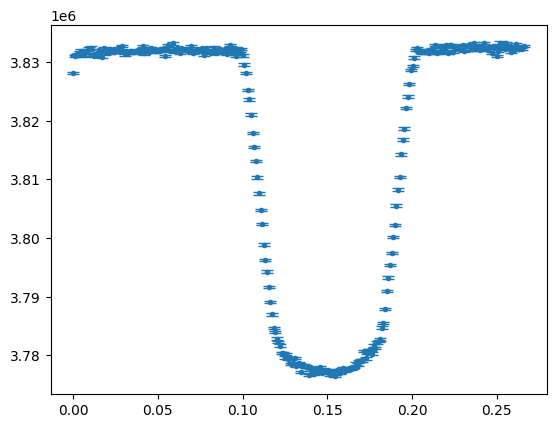

In [ ]:
# Step 5: Obtain WLC

WLC = np.nansum(fluxes, axis=1)
WLC_err = np.sqrt(np.nansum(fluxes_err**2, axis=1))

wlc_o2 = np.nansum(fluxes_o2, axis=1)
wlce_o2 = np.sqrt(np.nansum(fluxes_err_o2**2, axis=1))

plt.errorbar(time, WLC, yerr=WLC_err, fmt='.', capsize=4)
plt.show()
mpld3.display()
# plt.errorbar(time, wlc_o2, yerr=wlce_o2, fmt='.', capsize=4)
# mpld3.display()

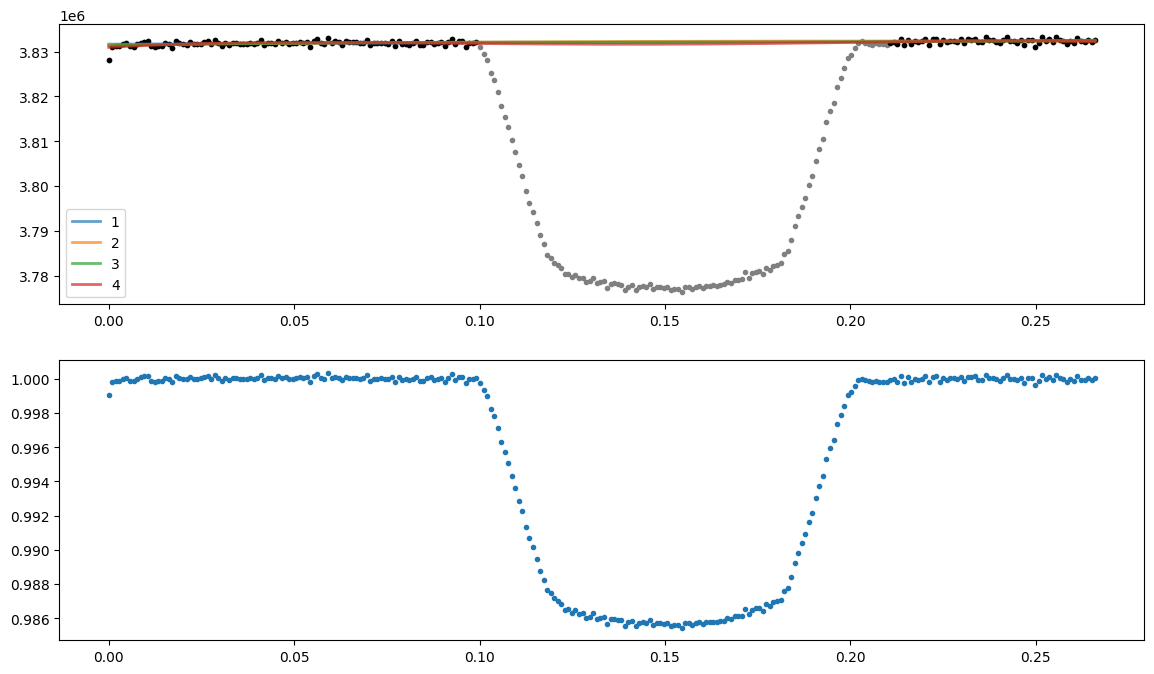

In [ ]:
# Step 6: normalizing to out of transit trend (hint: try multiple polynomial orders)
t1        = 0.10        # transit start
t2        = 0.21        # transit end
f_oot     = WLC[np.logical_or(time<t1,time>t2)]
t_oot     = time[np.logical_or(time<t1,time>t2)]
fig, (ax0, ax1) = plt.subplots(2,1, figsize=(14,8))
ax0.plot(time, WLC, 'o', c='grey', ms=3)
ax0.plot(t_oot, f_oot, 'o', c='k', ms=3)
for poly_order in [1,2,3,4]:
  oot_model = np.poly1d(np.polyfit(t_oot, f_oot, poly_order))
  ax0.plot(time, oot_model(time), lw=2, alpha=0.7, label=poly_order)
ax0.legend()
poly_order = 1 # decide on the polynomial order
oot_model  = np.poly1d(np.polyfit(t_oot, f_oot, poly_order))
ax1.plot(time, WLC/oot_model(time), 'o', ms=3)
F  = WLC/oot_model(time)
T  = time
F_err = WLC_err/oot_model(time)

In [ ]:
# Step 7: fitting the broadband transit LC with a transit model
!pip install batman-package  # for an analytical model of a transit
!pip install dynesty         # for running nested sampling
!pip install corner          # for plotting corner plots
!pip install ldtk            # for calculating LD coefficients

In [ ]:
# calculate limb darkening coefficients for the star, given the wavelength of observations

teff = 5500 # in K
logg = 4.4 # in cgs
metallicity =  0.21 # in dex solar


from ldtk import LDPSetCreator, BoxcarFilter

filters = [BoxcarFilter('a', wave1[0]*1e3, wave1[-1]*1e3)]

sc = LDPSetCreator(dataset='visir-lowres', # need to get the infrared version in low-res
                   teff=(teff,   100),
                   logg=(logg, 0.20),
                      z=(metallicity, 0.1),
                     filters=filters)

ps = sc.create_profiles()
cq,eq = ps.coeffs_qd()
print('u1 = %.5f, u2 = %.5f'%(cq[0][0],cq[0][1]))

u1 = 0.25299, u2 = 0.18158


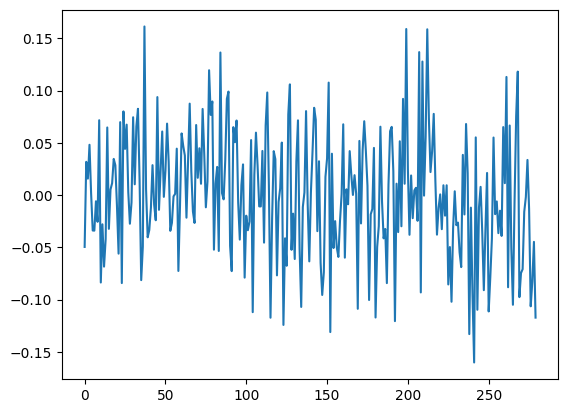

In [ ]:
import pandas as pd
pca = pd.read_csv('/content/summer-schoool-2025/JWST/WASP-96b/WASP-96_stability_pca.csv')
plt.plot(pca['Component 2'])

 ! For using the actual filter throughputs for the JWST instruments instead of a boxcar filter, a lot of us use [ExoTiC-LD](https://exotic-ld.readthedocs.io/en/latest/index.html) for generating limb-darkening parameters. This package also allows the usage of different stellar models. Due to the large size of the stellar files to download, we refrain to use this package here but do check it out!  

In [ ]:
import batman
PER = 3.42525674 # define period as hardcoded
t0_guess = 0.154
rp_guess = 0.1175
aRs_guess = 9.255
inc_guess = 85.6
systematics = np.array(pca['Component 3'])


def transit_model_full_with_systematics(theta, t):
  """
  wrapper for defining a transit model with all parameters free
  """
  t0, rp, a, inc, u1, u2, c0, c1, d1 = theta
  params     = batman.TransitParams()
  params.t0  = t0
  params.per = PER
  params.rp  = rp
  params.a   = a
  params.inc = inc
  params.u   = [u1, u2]
  params.limb_dark = "quadratic"
  params.ecc = 0
  params.w   = 90.
  m          = batman.TransitModel(params, t)
  lc         = m.light_curve(params)

  model = lc*c0+c1*t+d1*systematics

  return model

t_= time
plt.figure(figsize=(14,5))
plt.errorbar(T, F, yerr=F_err, fmt='.k', ms=6)
params = [t0_guess, rp_guess, aRs_guess, inc_guess, cq[0][0], cq[0][1], 1, -0.005, 0.01] # initial guess values for the free parameters
plt.plot(t_, transit_model_full_with_systematics(params, t_), lw=2, alpha=0.7, label='Model with initial guess values')
plt.xlabel('Time')
plt.ylabel('Normalized Flux')
plt.legend()
mpld3.display()

## Bayesian parameter estimation

The system characterisation is a parameter estimation problem, where we assume we have an adequate model to describe the observations, and we want to infer the model parameters with their uncertainties. This model was discussed in the lecture earlier.

We take a [Bayesian](http://en.wikipedia.org/wiki/Bayesian_probability) approach to parameter estimation, where we want to estimate the [posterior probability](http://en.wikipedia.org/wiki/Posterior_probability) for the model parameters given their [prior probabilities](http://en.wikipedia.org/wiki/Prior_probability) and a set of observations. The posterior probability density given a parameter vector $\theta$ and observational data $D$ is described by [Bayes' theorem](http://en.wikipedia.org/wiki/Bayes%27_theorem) as:

$$ P(\theta | D ) = \frac{P(\theta)P(D|\theta)}{P(D)} $$

where $P(\theta)$ is the prior, $P(D|\theta)$ is the [likelihood](http://en.wikipedia.org/wiki/Likelihood_function) for the data, and $P(D)$ is a [normalising factor](http://en.wikipedia.org/wiki/Marginal_likelihood) that we don't care about during MCMC-based parameter estimation. This is because be work with derivatives (for miminization) and the derivative of a constant is 0.

The likelihood is a product of individual observation probabilities, and has the unfortunate tendency to end up being either very small or very big. This causes computational headaches, and it is better to work with log probabilities instead. Taking the logarithm of the Bayesian relation above has the added advantage of converting the division to addition which is much easier to differentiate:

$$
\log P(\theta|D) = \log P(\theta) + \log P(D|\theta),  \qquad \textrm{with} \quad \log P(D|\theta) = \sum \log P(D_i|\theta)
$$

This is to say that $\log (posterior) = \log(prior) + \log(likelihood)$.  Note that we left out "$-\log P(D)$" since its derivate will be 0.

### The likelihood

Now we need to decide on the form of the likelihood density function. If we can assume [normally distributed](https://en.wikipedia.org/wiki/Normal_distribution) white noise--that is, the errors in the observations are independent and identically distributed--we end up with a log likelihood function:

$$
 \log P(D|\theta) = -N\log(\sigma) -\frac{N\log 2\pi}{2} - \sum_{i=0}^N \frac{(o_i-m_i)^2}{2\sigma^2},
$$

where $N$ is the number of datapoints, $\sigma$ is the white noise standard deviation, $o$ is the observed data, and $m$ is the model. (I hope that it is clear that the above relation is just the logarithm of the Gaussian function.)


In [ ]:
from scipy.special import erfinv
class UniformPrior:
    def __init__(self, a, b):
        self.a = a
        self.b = b

    def __call__(self, x):
        return self.a + (self.b-self.a) * x


class GaussianPrior:
    def __init__(self, mu, sigma):
        self.mu = mu
        self.sigma = sigma

    def __call__(self, x):
        return self.mu + self.sigma * np.sqrt(2) * erfinv(2*x-1)

8425it [05:55, 23.67it/s, +180 | bound: 1033 | nc: 1 | ncall: 285489 | eff(%):  3.016 | loglstar:   -inf < 1655.242 <    inf | logz: 1604.287 +/-  0.946 | dlogz:  0.335 > 10.000]


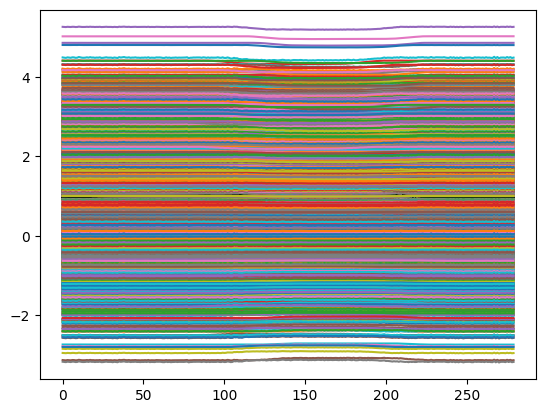

In [ ]:
import dynesty
def call_dynesty_wlc(time, data_values, data_err, nDims):

    def loglikelihood(theta):

        model = transit_model_full_with_systematics(theta, time) # this is for updating your light curve model with the new sampled values

        residuals = data_values - model
        plt.plot(model)
        #print(theta)


        N = len(data_values)
        logL = -N/2. *  np.log(2*np.pi)
        logL += - np.sum(np.log(data_err)) - np.sum(residuals**2 / (2 * data_err**2))
        return logL


    def prior(x): # transform the drawn values on your own parameter priors

        theta = [0] * nDims

        # t0, rp, a, inc, u1, u2, c0, c1, d1

        index_run = 0
        # e.g. Gaussian prior around the expected mid-transit time, inclination, a/Rs
        theta[index_run] = GaussianPrior(t0_guess,0.01)(np.array(x[index_run]))
        index_run += 1

        theta[index_run] =  GaussianPrior(rp_guess,0.01)(np.array(x[index_run]))
        index_run += 1

        theta[index_run] =  GaussianPrior(aRs_guess,0.1)(np.array(x[index_run]))
        index_run += 1

        theta[index_run] =  GaussianPrior(inc_guess,0.1)(np.array(x[index_run]))
        index_run += 1


        # limb-darkening, using cq[0][0], cq[0][1] as priors
        theta[index_run] =  GaussianPrior(cq[0][0],0.01)(np.array(x[index_run]))
        theta[index_run+1] =  GaussianPrior(cq[0][1],0.01)(np.array(x[index_run+1]))
        index_run += 2

        # linear in time
        theta[index_run] =  GaussianPrior(0.95, 1.1)(np.array(x[index_run]))
        theta[index_run+1] =  UniformPrior(-0.01,0.01)(np.array(x[index_run+1]))
        index_run += 2

        # systematics model
        theta[index_run] =  UniformPrior(0.0000001,0.1)(np.array(x[index_run]))
        index_run += 1

        # add other parameters here e.g. offsets, linear in time, etc.
        return theta


    sampler = dynesty.NestedSampler(loglikelihood, prior, nDims,nlive=20*nDims)
    sampler.run_nested(dlogz=1e+1, print_progress=True)
    sresults = sampler.results

    return sresults

results = call_dynesty_wlc(time, F, F_err, 9)



In [ ]:
samples, weights = results.samples, results.importance_weights()
from dynesty import utils as dyfunc
mean, cov = dyfunc.mean_and_cov(samples, weights)
equal_weights_samples = results.samples_equal()
best_fit_WLC_values = np.array(mean)

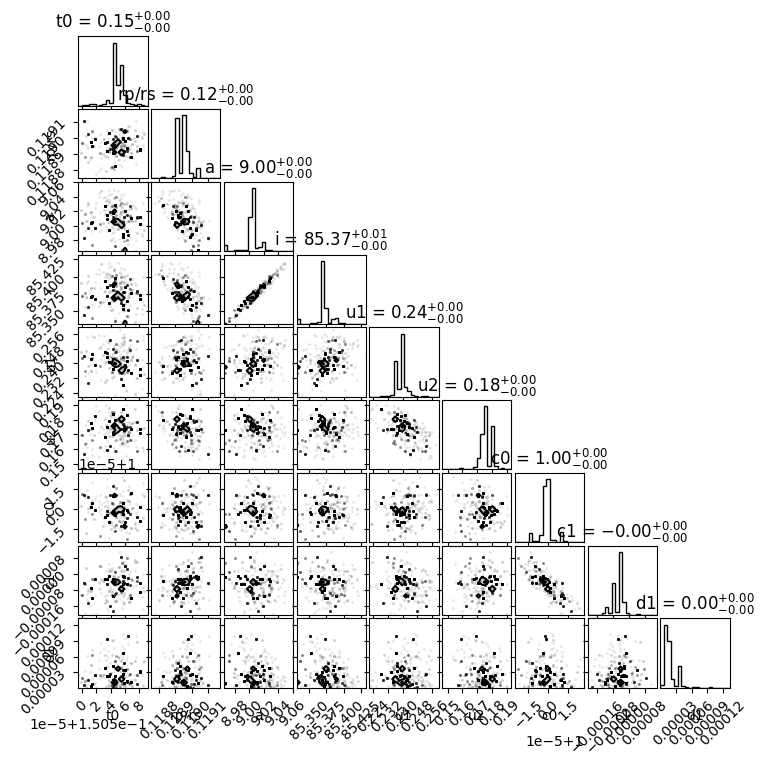

In [ ]:
# plot posterior distributions
from corner import corner
fig = corner(equal_weights_samples, labels=["t0", "rp/rs", "a", "i", "u1", "u2", 'c0', 'c1', 'd1'], fill_contours=True, show_titles=True,)
fig.set_size_inches(7,7)
plt.show()

[ 1.50549246e-01  1.18944554e-01  9.00374227e+00  8.53715228e+01
  2.39339256e-01  1.76105954e-01  9.99998532e-01 -5.53592679e-05
  1.91201770e-05]


Text(0.5, 0, 'Time from mid-transit [hours]')

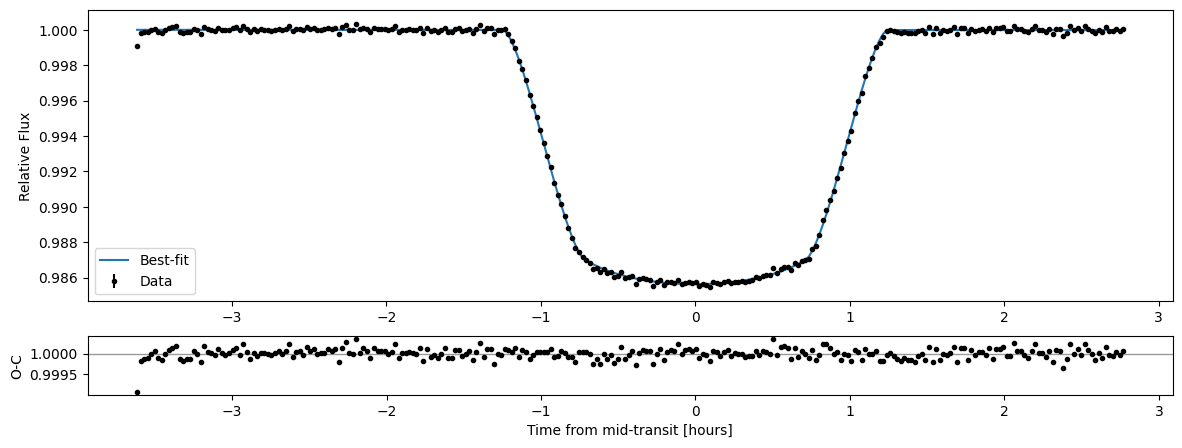

In [ ]:
# Plot best-fit model
t0, rp, a, inc, u1, u2, c0, c1, d1 = best_fit_WLC_values
print(best_fit_WLC_values)
best_flux  = transit_model_full_with_systematics(best_fit_WLC_values, time)

fig, (ax0, ax1) = plt.subplots(2,1,figsize=(14,5),height_ratios=[5,1])
ax0.errorbar(24*(T-t0), F, yerr=F_err, fmt=".k", label="Data")
ax0.plot(24*(T-t0), best_flux, "C0", label="Best-fit")


# optional: draw random results from the samples to obtain model uncertainties, for visual purposes.
draw     = np.floor(np.random.uniform(0,len(samples),size=1000)).astype(int)
thetas   = samples[draw]
models   = []
for i in thetas:
  t0, rp, a, inc, u1, u2, c0, c1, d1 = i
  models.append(transit_model_full_with_systematics(i, t_))
spread = np.std(models,axis=0)
#med_model = np.median(models,axis=0)

#ax0.fill_between(24*(T-t0),best_flux-spread,best_flux+spread,color='grey',alpha=0.5,label=r'$1\sigma$ Posterior Spread')
ax0.set_ylabel("Relative Flux")
ax0.legend()
# calculate residuals of the model
residuals  = F / transit_model_full_with_systematics(mean, time)
ax1.axhline(1.0, lw=1, c='grey', alpha=0.8)
ax1.plot(24*(T-t0), residuals, ".k", label="Residuals")
ax1.set_ylabel("O-C")
ax1.set_xlabel("Time from mid-transit [hours]")

In [ ]:
# Steps 8, 9 & 10: Obtain spectral LCs, remove common mode residuals and model them, fitting only wavelength-dependent parameters

step=0.1 # micron

def transit_model_spec_with_systematics(theta, t):
  rp, u1, u2, c0, c1, d1 = theta
  params     = batman.TransitParams()
  params.t0  = best_fit_WLC_values[0]
  params.per = PER
  params.rp  = rp
  params.a   = best_fit_WLC_values[2]
  params.inc = best_fit_WLC_values[3]
  params.u   = [u1, u2]
  params.limb_dark = "quadratic"
  params.ecc = 0
  params.w   = 90.
  m          = batman.TransitModel(params, t)
  lc         = m.light_curve(params)

  model = lc*c0+c1*t+d1*systematics
  return model

import dynesty

def call_dynesty_spec(time, data_values, data_err, nDims, ld_guess):

    def loglikelihood(theta):

        model = transit_model_spec_with_systematics(theta, time) # this is for updating your light curve model with the new sampled values

        residuals = data_values - model
        plt.plot(model)

        N = len(data_values)
        logL = -N/2. *  np.log(2*np.pi)
        logL += - np.sum(np.log(data_err)) - np.sum(residuals**2 / (2 * data_err**2))
        return logL


    def prior(x): # transform the drawn values on your own parameter priors

        theta = [0] * nDims

        # rp, u1, u2, c0, c1, d1

        index_run = 0
        # e.g. Gaussian prior around the expected mid-transit time, inclination, a/Rs

        theta[index_run] = UniformPrior(0.116,0.123)(np.array(x[index_run]))
        index_run += 1

        # limb-darkening, using ld_guess as priors
        theta[index_run] =  GaussianPrior(ld_guess[0],0.01)(np.array(x[index_run]))
        theta[index_run+1] =  GaussianPrior(ld_guess[1],0.01)(np.array(x[index_run+1]))
        index_run += 2

        # linear in time
        theta[index_run] =  GaussianPrior(0.99, 1.1)(np.array(x[index_run]))
        theta[index_run+1] =  UniformPrior(-0.01,0.01)(np.array(x[index_run+1]))
        index_run += 2

        # systematics model
        theta[index_run] =  UniformPrior(0.0000001,0.0001)(np.array(x[index_run]))
        index_run += 1

        # add other parameters here e.g. offsets, linear in time, etc.
        return theta


    sampler = dynesty.NestedSampler(loglikelihood, prior, nDims,nlive=20*nDims)
    sampler.run_nested(dlogz=1e+0, print_progress=True)
    sresults = sampler.results

    return sresults






offset = 0.
TS     = []
fig, (ax0, ax1) = plt.subplots(1,2, figsize=(12,9))
ax0.set_ylabel('Normalized flux (+offset)')
ax1.set_ylabel('O - C (+offset)')
ax0.set_xlabel('Time [hours from mid-transit]')
ax1.set_xlabel('Time [hours from mid-transit]')
ax0.set_title('CMC Spectroscopic light curves')
ax1.set_title('Model residuals')



for x1 in np.arange(wave1[0],wave1[-1],step=step):
  print('Processing the bin centered on '+str(x1+step/2))
  x2  = x1 + step

  wvl_start_pixel = np.where(wave1 >= x1)[0][0]
  wvl_end_pixel = np.where(wave1 <= x2)[0][-1]
  LC = np.nansum(fluxes[:,wvl_start_pixel:wvl_end_pixel],axis=1)

  e_LC      = np.sqrt(np.nansum(fluxes_err[:,wvl_start_pixel:wvl_end_pixel]**2,axis=1))

  f_oot     = LC[np.logical_or(time<t1,time>t2)]
  oot_model = np.poly1d(np.polyfit(t_oot, f_oot, poly_order)) # using the same order polynomial as white LC
  F_        = LC/oot_model(time)
  F_err_    = e_LC/oot_model(time)

  # calculate limb darkening coefficients for the wavelengths of each bin
  print(x1, x2)
  filter = [BoxcarFilter('a', x1*1e3, x2*1e3)]

  sc = LDPSetCreator(dataset='visir-lowres',
                     teff=(teff,   100),
                     logg=(logg, 0.20),
                        z=(metallicity, 0.1),
                      filters=filter)

  ps = sc.create_profiles()
  cq,eq = ps.coeffs_qd()
  ld_guess = [cq[0][0], cq[0][1]]

  result = call_dynesty_spec(time, F_, F_err_, 6, ld_guess)

  samples, weights = result.samples, result.importance_weights()
  mean, cov = dyfunc.mean_and_cov(samples, weights)
  equal_weights_samples = result.samples_equal()

  # obtain best fit parameters
  rp, u1, u2, c0, c1, d1 = mean
  best_flux  = transit_model_spec_with_systematics(mean, t_)

  # plot spectroscopic light curves, together with best fit models
  ax0.errorbar(24*(time-t0), F_+offset, yerr=F_err_, fmt=".k", zorder=1)
  ax0.plot(24*(t_-t0), best_flux+offset, c="C0", lw=2, alpha=0.8, zorder=2)

  # plot the residuals of each fit
  ax1.errorbar(24*(time-t0), F_-transit_model_spec_with_systematics(mean, time)+1.+offset, yerr=F_err_, fmt=".k", zorder=2, alpha=0.8)
  ax1.axhline(1.+offset, c="C0", lw=2, zorder=1)

  offset += 0.01

  # store bin information and planet radius results, together with their errors into an array
  TS.append(np.array([float(x1+step),rp,np.percentile(samples,16,axis=0)[0]-rp,np.percentile(samples,84,axis=0)[0]-rp,np.std(samples,axis=0)[0]]))


Processing the bin centered on 0.896722960472107
0.8467229604721069 0.9467229604721069


2513it [00:19, 126.34it/s, +120 | bound: 69 | nc: 1 | ncall: 16560 | eff(%): 16.016 | loglstar:   -inf < 1830.172 <    inf | logz: 1809.317 +/-  0.422 | dlogz:  0.008 >  1.000]


Processing the bin centered on 0.9967229843139649
0.9467229843139648 1.046722984313965


2423it [00:15, 152.77it/s, +120 | bound: 52 | nc: 1 | ncall: 13836 | eff(%): 18.540 | loglstar:   -inf < 1851.334 <    inf | logz: 1831.225 +/-  0.414 | dlogz:  0.008 >  1.000]


Processing the bin centered on 1.0967230081558228
1.0467230081558228 1.1467230081558228


2687it [00:23, 114.98it/s, +120 | bound: 85 | nc: 1 | ncall: 19653 | eff(%): 14.371 | loglstar:   -inf < 1888.124 <    inf | logz: 1865.704 +/-  0.440 | dlogz:  0.009 >  1.000]


Processing the bin centered on 1.1967230319976807
1.1467230319976807 1.2467230319976808


2811it [11:32,  2.93it/s, bound: 2367 | nc: 1120 | ncall: 430468 | eff(%):  0.653 | loglstar:   -inf < 1900.161 <    inf | logz: 1876.415 +/-  0.429 | dlogz:  5.956 >  1.000]

Text(0.5, 0, 'Wavelength [micron]')

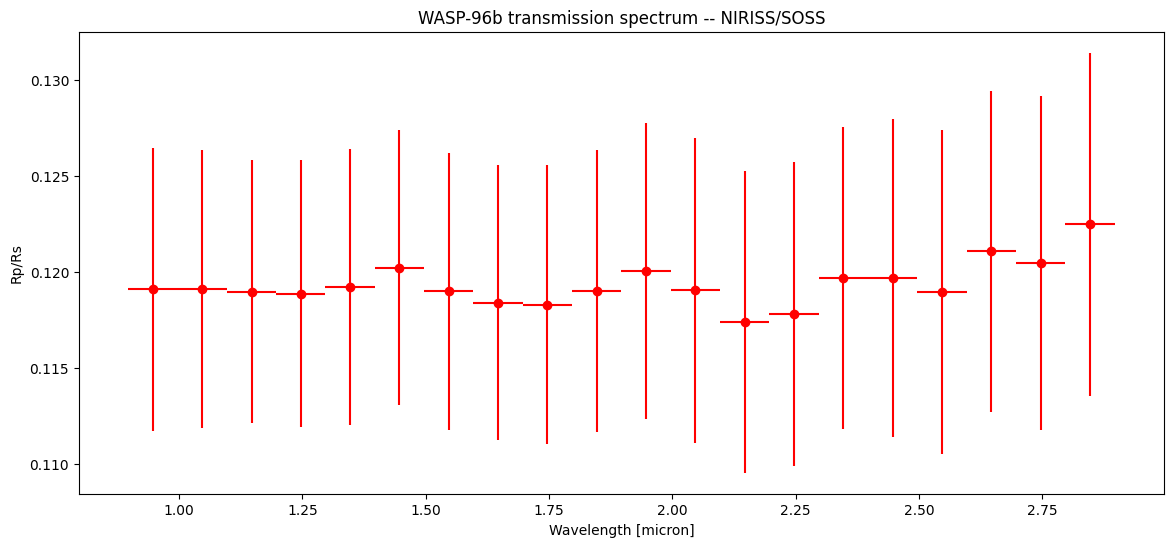

In [ ]:
# Step 11: Obtain and plot the transmission spectrum
TS = np.array(TS)
plt.figure(figsize=(14,6))
plt.title('WASP-96b transmission spectrum -- NIRISS/SOSS')
plt.plot(TS[:,0], TS[:,1], '.', ms=3)
plt.errorbar(TS[:,0], TS[:,1], yerr=TS[:,4], xerr=step/2, fmt='o', c='red')
plt.ylabel('Rp/Rs')
plt.xlabel('Wavelength [micron]')